TEST B : residualisation puis PCA

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from neurostatx.io.loader import DatasetLoader
from neurostatx.utils.preprocessing import merge_dataframes

from scipy import stats
from statsmodels.regression.linear_model import OLS

from sklearn.impute import KNNImputer  
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [2]:
# Setting up relevant paths
repository_path = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/GitHub/FuzzyClustering-PING"
data_filtered_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"
output_dir = "c:/Users/Rosalie/OneDrive - Office 365/Documents/UdeS/Hiver 2026/Crédits de recherche/result/CCA/"

# Create output directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# Load ping data
ping_ori = pd.read_excel(f"{data_filtered_dir}/ping_data_filtered_for_bundles.xlsx")

# Load bundles
bundles_ori = pd.read_excel(f"{data_filtered_dir}/bundles_data_filtered_for_ping.xlsx")

In [4]:
# convertir en numérique
measure_cols = bundles_ori.columns[3:]
bundles_ori[measure_cols] = bundles_ori[measure_cols].apply(pd.to_numeric, errors="coerce")
bundles_scaled = bundles_ori.copy()

# Standardiser les donnees des bundles avec mean=0 et std=1 pour les colonnes de mesures
bundles_scaled[measure_cols] = pd.DataFrame(StandardScaler().fit_transform(bundles_ori[measure_cols]))

In [5]:
selected_cols = ["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]
bundles_scaled = bundles_scaled[["sample", "bundle"] + selected_cols]

# Pivoter et reformuler les lignes et colonnes pour les mesures des bundles
sample_col = bundles_scaled.columns[0]
bundle_col = bundles_scaled.columns[1]
measure_cols = bundles_scaled.columns[2:]

# pivot : une ligne par sample, colonnes = bundle x mesure
bundles_pivot = bundles_scaled.pivot(index=sample_col, columns=bundle_col, values=measure_cols)

In [6]:
# Filtrer les colonnes avec 20% ou plus de valeurs manquantes
missing_pct = bundles_pivot.isna().mean() * 100
cols_to_keep = missing_pct[missing_pct < 20].index
bundles_20 = bundles_pivot.loc[:, cols_to_keep].copy()

# colonnes supprimées
cols_removed = missing_pct[missing_pct >= 20].index

print("Nombre de colonnes supprimées :", len(cols_removed))
print("Colonnes supprimées :")
print(list(cols_removed))

Nombre de colonnes supprimées : 28
Colonnes supprimées :
[('fa', 'AC'), ('fa', 'CG_L_curve'), ('fa', 'CG_R_curve'), ('fa', 'PC'), ('md', 'AC'), ('md', 'CG_L_curve'), ('md', 'CG_R_curve'), ('md', 'PC'), ('ad', 'AC'), ('ad', 'CG_L_curve'), ('ad', 'CG_R_curve'), ('ad', 'PC'), ('rd', 'AC'), ('rd', 'CG_L_curve'), ('rd', 'CG_R_curve'), ('rd', 'PC'), ('afd_fixel', 'AC'), ('afd_fixel', 'CG_L_curve'), ('afd_fixel', 'CG_R_curve'), ('afd_fixel', 'PC'), ('afd_total', 'AC'), ('afd_total', 'CG_L_curve'), ('afd_total', 'CG_R_curve'), ('afd_total', 'PC'), ('nufo', 'AC'), ('nufo', 'CG_L_curve'), ('nufo', 'CG_R_curve'), ('nufo', 'PC')]


In [ ]:
# A SUPPRIMER
selected_cols = ["fa", "md", "ad", "afd_fixel", "afd_total", "nufo"]
bundles_scaled = bundles_scaled[["sample", "bundle"] + selected_cols]

# reformuler les lignes et colonnes pour les mesures des bundles
sample_col = bundles_scaled.columns[0]
bundle_col = bundles_scaled.columns[1]
measure_cols = bundles_scaled.columns[2:].tolist()

# Nombre total de sujets uniques
all_samples = sorted(bundles_scaled[sample_col].unique())
n_samples_total = len(all_samples)

# Nombre de sujets uniques où chaque bundle est présent
bundle_presence = bundles_scaled.groupby(bundle_col)[sample_col].nunique()

# Taux de présence par bundle
bundle_presence_rate = bundle_presence / n_samples_total

# Garder les bundles présents chez au moins 80 % des sujets
bundles_to_keep = bundle_presence_rate[bundle_presence_rate >= 0.80].index.tolist()

# Filtrer le dataframe
bundles_80 = bundles_scaled[bundles_scaled[bundle_col].isin(bundles_to_keep)].copy()

# Créer toutes les combinaisons sample x bundle attendues
full_index = pd.MultiIndex.from_product(
    [all_samples, bundles_to_keep],
    names=[sample_col, bundle_col]
)

# Recréer les lignes manquantes, puis remettre sample et bundle comme 2 colonnes
bundles_all = (
    bundles_80
    .set_index([sample_col, bundle_col])
    .reindex(full_index)
    .reset_index()
)

bundles_removed = bundle_presence_rate[bundle_presence_rate < 0.80]
print(bundles_removed.sort_values())

In [ ]:
# A SUPPRIMER
measure_cols = bundles_all.columns[2:]
k_values = [1, 2, 3, 4, 6, 8, 10]
all_results = []

for seed in range(20):
    rng = np.random.default_rng(seed)

    complete_rows = bundles_all.index[bundles_all[measure_cols].notna().all(axis=1)]
    n_mask_rows = max(2, int(len(complete_rows) * 0.10))
    masked_rows = rng.choice(complete_rows, size=n_mask_rows, replace=False)

    X_test = bundles_all.copy()
    X_masked = bundles_all.copy()
    X_masked.loc[masked_rows, measure_cols] = np.nan

    for k in k_values:
        imputer = KNNImputer(
         n_neighbors=k,
         weights="distance",
         metric="nan_euclidean"
     )

        X_imputed = X_masked.copy()
        X_imputed[measure_cols] = imputer.fit_transform(X_masked [measure_cols])

        true_vals = X_test.loc[masked_rows, measure_cols].to_numpy().ravel()
        pred_vals = X_imputed.loc[masked_rows, measure_cols].to_numpy().ravel()

        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        all_results.append({"seed": seed, "k": k, "rmse": rmse})

all_results_df = pd.DataFrame(all_results)
summary = all_results_df.groupby("k", as_index=False)["rmse"].agg(["mean", "std"]).reset_index()

In [ ]:
# A SUPPRIMER
# Afficher les résultats et choisir le meilleur k
print(all_results_df[["k", "rmse"]])
best_k = all_results_df.loc[0, "k"]
print("Best k:", best_k)

In [ ]:
# A SUPPRIMER
summary = (
    all_results_df.groupby("k")["rmse"]
    .agg(["mean", "std", "min", "max"])
    .sort_values("mean")
)
print(summary)

In [7]:
# Préparer les mêmes masques pour tous les k
rng = np.random.default_rng(42)

# prendre seulement un sous-ensemble de colonnes pour choisir k
n_test_cols = min(20, bundles_20.shape[1])
test_cols = rng.choice(bundles_20.columns, size=n_test_cols, replace=False)

X_test = bundles_20[test_cols].copy()

# créer un seul plan de masquage
mask_fraction = 0.20
masked_positions = []

X_masked = X_test.copy()

for col in test_cols:
    observed_idx = X_test.index[X_test[col].notna()]
    if len(observed_idx) < 10:
        continue

    n_mask = max(2, int(len(observed_idx) * mask_fraction))
    chosen_idx = rng.choice(observed_idx, size=n_mask, replace=False)

    for idx in chosen_idx:
        masked_positions.append((idx, col))

    X_masked.loc[chosen_idx, col] = np.nan

In [8]:
# tester quelques k 
k_values = [7, 10, 15, 20, 25, 30, 35, 40]
results = []

for k in k_values:
    imputer = KNNImputer(
        n_neighbors=k,
        weights="distance",
        metric="nan_euclidean"
    )

    X_imputed = pd.DataFrame(
        imputer.fit_transform(X_masked),
        index=X_masked.index,
        columns=X_masked.columns
    )

    true_vals = np.array([X_test.loc[idx, col] for idx, col in masked_positions], dtype=float)
    pred_vals = np.array([X_imputed.loc[idx, col] for idx, col in masked_positions], dtype=float)

    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    results.append({"k": k, "rmse": rmse})

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


In [9]:
# Afficher les résultats et choisir le meilleur k
print(results_df[["k", "rmse"]])
best_k = results_df.loc[0, "k"]
print("Best k:", best_k)

    k      rmse
0  20  0.518410
1  25  0.519652
2  15  0.520690
3  30  0.521716
4  10  0.522364
5  35  0.524282
6  40  0.526063
7   7  0.532174
Best k: 20


In [10]:
# Impute the missing values in bundles using the best KNN imputer
imputer = KNNImputer(
    n_neighbors=best_k,
    weights="distance",
    metric="nan_euclidean"
)

bundles_imputed = pd.DataFrame(
    imputer.fit_transform(bundles_20),
    columns=bundles_20.columns,
    index=bundles_20.index
)

In [11]:
# Merge ping et bundles
ping_ori["sample"] = ping_ori["Sample"].astype(str)
ping_ori = ping_ori.set_index("sample")

bundles_imputed.index = bundles_imputed.index.astype(str)
bundles_imputed.index.name = "sample"

# remettre sample comme colonne pour merge_dataframes
ping_for_merge = ping_ori.reset_index()
bundles_for_merge = bundles_imputed.reset_index() 

ping_and_bundles = merge_dataframes({"ping" : ping_for_merge, "bundles" : bundles_for_merge}, index="sample")

ping_and_bundles = ping_and_bundles.drop(columns=["Sample"])


In [12]:
# Residualisation des bundles pour age, sex, handedness
# Separate the covariates and the variates data
covars = ping_and_bundles[["Sex", "AgeMonths", "Ethnicity", "Handedness"]].copy()
vars = ping_and_bundles.iloc[:, 14:].copy()

covars = sm.add_constant(covars)

# Instantiating an empty dataframe to store the results
residuals = pd.DataFrame(index=ping_and_bundles.index)

# Running a linear regression model for eact variate
for var in vars.columns:
    model = OLS(vars[var], covars)
    results = model.fit()
    residuals[var] = results.resid

C:\Users\Rosalie\AppData\Local\Temp\ipykernel_14104\728060133.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_14104\728060133.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  residuals[var] = results.resid
C:\Users\Rosalie\AppData\Local\Temp\ipykernel_14104\728060133.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

In [ ]:
# Merging the residuals with the original data
ping_bundles_resid_pre_PCA = pd.concat([ping_and_bundles.drop(columns=vars), residuals], axis=1)

In [15]:
# Verifier que la residiualisation a bien fonctionné
X = sm.add_constant(ping_and_bundles[["AgeMonths", "Sex", "Ethnicity", "Handedness"]])

for col in residuals.columns:
    model = sm.OLS(residuals[col], X).fit()
    print(f"\n{col}")
    print(model.summary().tables[1])
# Coef environ 0 = pas de relation entre les covariables et les variables d'intérêt, ce qui est le but de la residualisation.
# P values élevés (1) = pas de relation significative entre les covariables et les variables d'intérêt, ce qui est également le but de la residualisation.


('fa', 'AF_L')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -5.317e-16      0.134  -3.96e-15      1.000      -0.264       0.264
AgeMonths  -1.113e-15      0.000  -2.43e-12      1.000      -0.001       0.001
Sex        -4.113e-16      0.040  -1.04e-14      1.000      -0.078       0.078
Ethnicity   1.375e-16      0.012   1.16e-14      1.000      -0.023       0.023
Handedness -1.245e-16      0.053  -2.37e-15      1.000      -0.103       0.103

('fa', 'AF_R')
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.163e-16      0.131  -3.19e-15      1.000      -0.257       0.257
AgeMonths  -1.183e-15      0.000  -2.66e-12      1.000      -0.001       0.001
Sex        -6.702e-16      0.039  -1.74e-14      1.000      -0.076       0.076
Ethnicity   1.505e-1

In [34]:
# convertir les colonnes tuple en vrai MultiIndex
residuals.columns = pd.MultiIndex.from_tuples(
    residuals.columns,
    names=["measure", "bundle"]
)

# revenir au format long
bundles_unpivot = (
    residuals
    .stack(level="bundle")
    .reset_index()
)

# remettre les colonnes dans l'ordre voulu
selected_cols = ["fa", "md", "ad", "rd", "afd_fixel", "afd_total", "nufo"]
bundles_unpivot = bundles_unpivot.rename(columns={"bundle": "bundle"})
bundles_unpivot = bundles_unpivot[["sample", "bundle"] + selected_cols]


C:\Users\Rosalie\AppData\Local\Temp\ipykernel_14104\2961337692.py:10: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level="bundle")


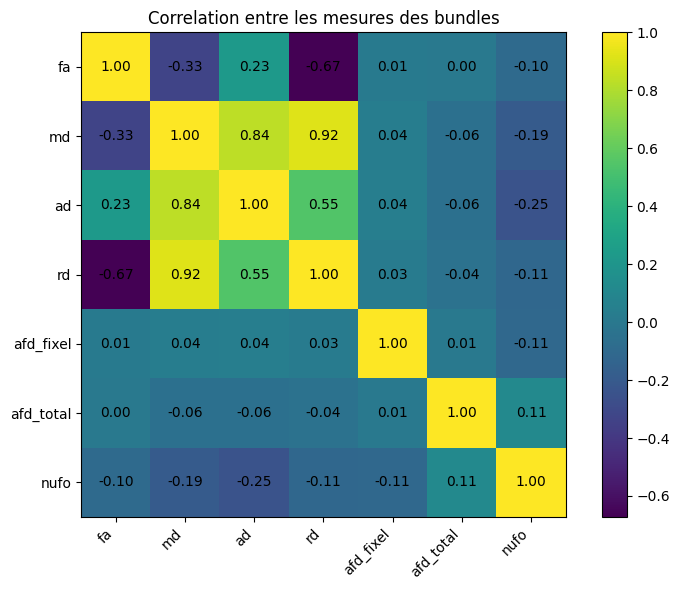

In [28]:
import matplotlib.pyplot as plt

measure_cols = bundles_unpivot.columns[2:]
corr_matrix = bundles_unpivot[measure_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, interpolation="nearest")
plt.colorbar(im)

ax.set_xticks(range(len(measure_cols)))
ax.set_yticks(range(len(measure_cols)))
ax.set_xticklabels(measure_cols, rotation=45, ha="right")
ax.set_yticklabels(measure_cols)

for i in range(len(measure_cols)):
    for j in range(len(measure_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center")

ax.set_title("Correlation entre les mesures des bundles")
plt.tight_layout()
plt.show()

In [35]:
# Performing PCA  
pca = PCA()
principal_components = pca.fit_transform(bundles_unpivot[selected_cols])
principal_df = pd.DataFrame(data=principal_components, columns=[f"PC{i+1}" for i in range(principal_components.shape[1])])

# Garder les composantes avec eigenvalues >= 1
n_keep = np.sum(pca.explained_variance_ >= 1)
if n_keep == 0:
    n_keep = 1

principal_df = pd.DataFrame(
    data=principal_components[:, :n_keep],
    columns=[f"PC{i+1}" for i in range(n_keep)],
      index=bundles_unpivot.index)

# Ajouter les colonnes "sample" et "bundle" au DataFrame des scores PCA
principal_df.insert(0, "sample", bundles_unpivot["sample"].values)
principal_df.insert(1, "bundle", bundles_unpivot.iloc[:, 1].values)

# variance expliquée
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_))],
    "Eigenvalue": pca.explained_variance_,
    "Explained_variance_ratio": pca.explained_variance_ratio_,
    "Cumulative_variance": pca.explained_variance_ratio_.cumsum()
})
# loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_cols,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

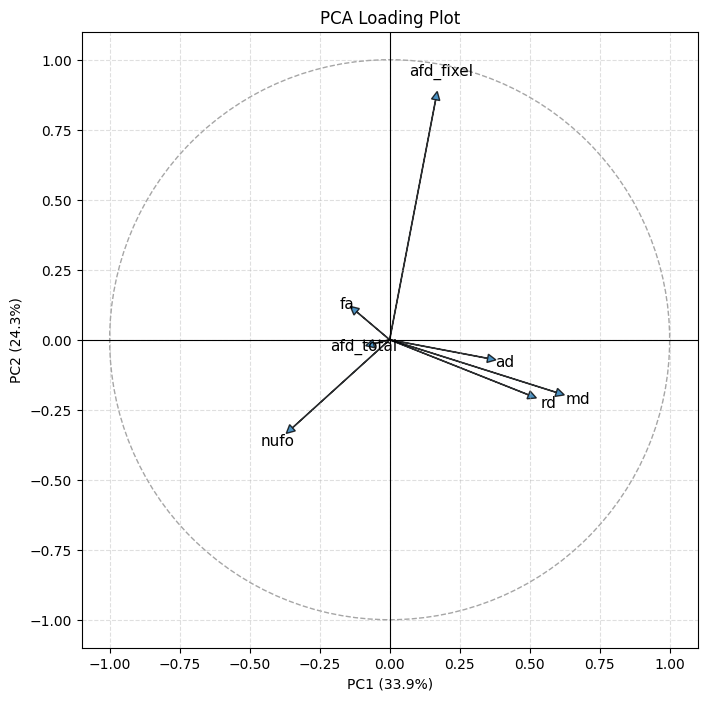

In [36]:
# Extraire les loadings de PC1 et PC2
pc1 = pca_loadings["PC1"]
pc2 = pca_loadings["PC2"]

# Figure
plt.figure(figsize=(8, 8))

# Cercle de corrélation simple
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.7)
plt.gca().add_artist(circle)

# Tracer les vecteurs
for var in selected_cols:
    x = pc1[var]
    y = pc2[var]
    
    plt.arrow(
        0, 0, x, y,
        head_width=0.03,
        head_length=0.03,
        length_includes_head=True,
        alpha=0.8
    )
    plt.text(
        x * 1.08,
        y * 1.08,
        var,
        fontsize=11,
        ha='center',
        va='center'
    )

# Axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

# Labels avec variance expliquée
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f"PC1 ({var_pc1:.1f}%)")
plt.ylabel(f"PC2 ({var_pc2:.1f}%)")
plt.title("PCA Loading Plot")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

CCA avec PC1

In [ ]:
# Perform Canonical Correlation Analysis avec 3 composantes (car 3 variables cognitives)

cols_after_14 = ping_bundles_resid.columns[14:]
pc1_cols = [col for col in cols_after_14 if isinstance(col, tuple) and col[0] == "PC1"]
X1 = ping_bundles_resid.loc[:, pc1_cols]
X1.index = ping_bundles_resid.index

Y1 = ping_bundles_resid[["VA", "EFPS", "MEM"]] # Y = variables cognitives
Y1.index = ping_bundles_resid.index

cca = CCA(n_components=3)
X1_c, Y1_c = cca.fit_transform(X1, Y1)

# Calculate and print the canonical correlations for each pair of canonical variables
canonical_corrs = []
for i in range(3):
    corr = np.corrcoef(X1_c[:, i], Y1_c[:, i])[0, 1]
    canonical_corrs.append(corr)
    print(f"Dimension canonique {i+1} : r = {corr:.3f}")